# **SESIÓN 01: INTRODUCCIÓN A DEEP LEARNING**


# **1. EL PERCEPTRON**

* La comunicación entre neuronas se llama sinapsis.
* Neuronas simples se combinan para generar neuronas más complejas.
* Una neurona posee tres partes: dendritas, cuerpo celular o soma, y el axón.
* Cuando la dendrita recibe un estímulo que supera cierto umbral, esta se activa y libera una acción que se transmite a través del axón.

Con neuronas simples se solucionan problemas de complejidad lineal.

Ejemplo: Operadores **AND** y **OR**
. No obstante, problemas más complejos, como el operador **XOR**, no poseen solución lineal.


  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import torch.nn as nn
from torch.autograd import Variable

## **1.1 El operador AND**

In [2]:
df = pd.DataFrame(columns = ["X1", "X2", "b", "W1", "W2", "SUMA PONDERADA", "Y"])
df["X1"] = np.array([ 0, 0, 1, 1])
df["X2"] = np.array([ 0, 1, 0, 1])
df["b"]  =-1
df["W1"] = 1
df["W2"] = 1

df["SUMA PONDERADA"] = df["b"] + df["X1"]*df["W1"] + df["X2"]*df["W2"]
df["Y"] = (df["SUMA PONDERADA"]>0).astype("int")
df

,X1,X2,b,W1,W2,SUMA PONDERADA,Y
0,0,0,-1,1,1,-1,0
1,0,1,-1,1,1,0,0
2,1,0,-1,1,1,0,0
3,1,1,-1,1,1,1,1


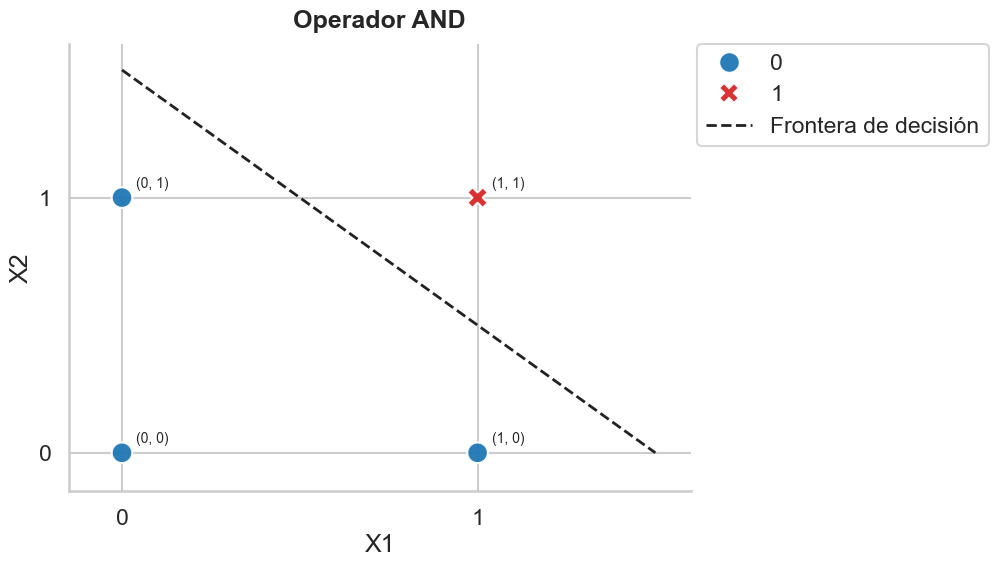

In [3]:
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(9.5, 5.8))
sns.scatterplot(
    data=df,
    x="X1",
    y="X2",
    hue="Y",
    style="Y",
    palette={0: "#1f77b4", 1: "#d62728"},
    s=220,
    edgecolor="white",
    linewidth=1.5,
    ax=ax,
    legend="full",
    alpha=0.95,
    )
ax.plot([0, 1.5], [1.5, 0], color="#222222", linestyle="--", linewidth=2, label="Frontera de decisión")
for _, row in df.iterrows():
    ax.text(row["X1"] + 0.04, row["X2"] + 0.04, f"({row['X1']}, {row['X2']})", fontsize=10)
ax.set_title("Operador AND", pad=12, weight="bold")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_xlim(-0.15, 1.6)
ax.set_ylim(-0.15, 1.6)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.legend(frameon=True, loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
sns.despine(ax=ax)
fig.subplots_adjust(right=0.78)
plt.show()

# **2 Funciones de activación**

## **2.1 SIGMOID**

In [4]:
# Valores de entrada para evaluar la función sigmoide
x = np.arange(-4, 5, 0.1)
# Cálculo de la sigmoide sobre el rango definido
sig = 1 / (1 + np.exp(-x))
# Mostramos los valores obtenidos
print(sig)

[0.01798621 0.01984031 0.02188127 0.02412702 0.02659699 0.02931223
 0.03229546 0.03557119 0.03916572 0.04310725 0.04742587 0.05215356
 0.05732418 0.06297336 0.06913842 0.07585818 0.0831727  0.09112296
 0.09975049 0.10909682 0.11920292 0.13010847 0.14185106 0.15446527
 0.16798161 0.18242552 0.19781611 0.21416502 0.23147522 0.24973989
 0.26894142 0.2890505  0.31002552 0.33181223 0.35434369 0.37754067
 0.40131234 0.42555748 0.450166   0.47502081 0.5        0.52497919
 0.549834   0.57444252 0.59868766 0.62245933 0.64565631 0.66818777
 0.68997448 0.7109495  0.73105858 0.75026011 0.76852478 0.78583498
 0.80218389 0.81757448 0.83201839 0.84553473 0.85814894 0.86989153
 0.88079708 0.89090318 0.90024951 0.90887704 0.9168273  0.92414182
 0.93086158 0.93702664 0.94267582 0.94784644 0.95257413 0.95689275
 0.96083428 0.96442881 0.96770454 0.97068777 0.97340301 0.97587298
 0.97811873 0.98015969 0.98201379 0.9836975  0.98522597 0.98661308
 0.98787157 0.98901306 0.9900482  0.9909867  0.99183743 0.9926

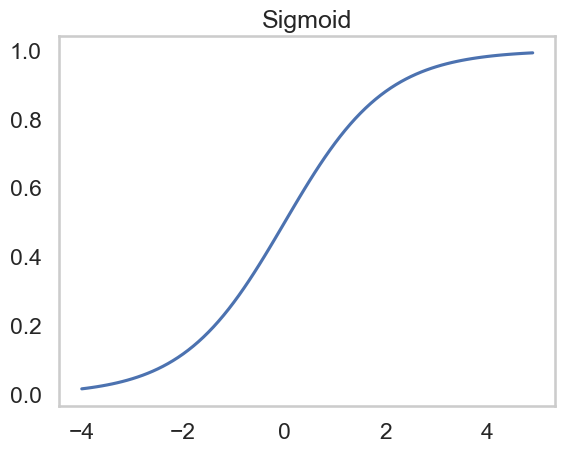

In [5]:
plt.plot(x,sig)
plt.title("Sigmoid")
plt.grid()
plt.show()

## **2.2 TANH**

In [6]:
# Valores de entrada para evaluar la función tanh
x = np.arange(-4, 5, 0.1)
# Cálculo de la tangente hiperbólica sobre el rango definido
tan = (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))
# Mostramos los valores obtenidos
print(tan)

[-9.99329300e-01 -9.99180866e-01 -9.98999598e-01 -9.98778241e-01
 -9.98507942e-01 -9.98177898e-01 -9.97774928e-01 -9.97282960e-01
 -9.96682398e-01 -9.95949359e-01 -9.95054754e-01 -9.93963167e-01
 -9.92631520e-01 -9.91007454e-01 -9.89027402e-01 -9.86614298e-01
 -9.83674858e-01 -9.80096396e-01 -9.75743130e-01 -9.70451937e-01
 -9.64027580e-01 -9.56237458e-01 -9.46806013e-01 -9.35409071e-01
 -9.21668554e-01 -9.05148254e-01 -8.85351648e-01 -8.61723159e-01
 -8.33654607e-01 -8.00499022e-01 -7.61594156e-01 -7.16297870e-01
 -6.64036770e-01 -6.04367777e-01 -5.37049567e-01 -4.62117157e-01
 -3.79948962e-01 -2.91312612e-01 -1.97375320e-01 -9.96679946e-02
  3.55271368e-15  9.96679946e-02  1.97375320e-01  2.91312612e-01
  3.79948962e-01  4.62117157e-01  5.37049567e-01  6.04367777e-01
  6.64036770e-01  7.16297870e-01  7.61594156e-01  8.00499022e-01
  8.33654607e-01  8.61723159e-01  8.85351648e-01  9.05148254e-01
  9.21668554e-01  9.35409071e-01  9.46806013e-01  9.56237458e-01
  9.64027580e-01  9.70451

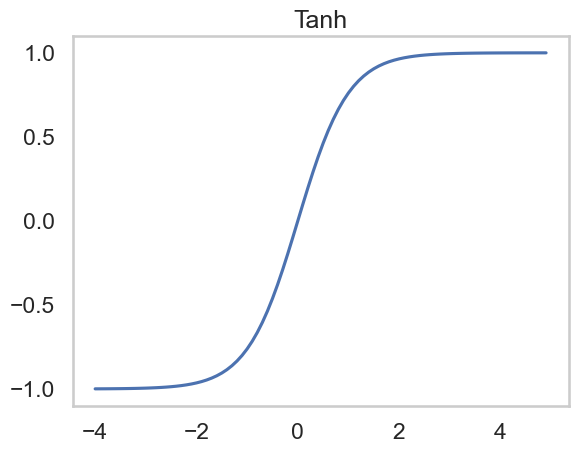

In [7]:
plt.plot(x,tan)
plt.title("Tanh")
plt.grid()
plt.show()

## **2.3 Relu**

In [8]:
# Valores de entrada para evaluar la función ReLU
x = np.arange(-4, 5, 0.1)
# Aplicamos ReLU: deja pasar solo los valores positivos
relu = np.maximum(0, x)
# Mostramos los valores obtenidos
print(relu)

[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 3.55271368e-15 1.00000000e-01 2.00000000e-01 3.00000000e-01
 4.00000000e-01 5.00000000e-01 6.00000000e-01 7.00000000e-01
 8.00000000e-01 9.00000000e-01 1.00000000e+00 1.10000000e+00
 1.20000000e+00 1.30000000e+00 1.40000000e+00 1.50000000e+00
 1.60000000e+00 1.70000000e+00 1.80000000e+00 1.90000000e+00
 2.00000000e+00 2.10000000e+00 2.20000000e+00 2.30000000e+00
 2.40000000e+00 2.500000

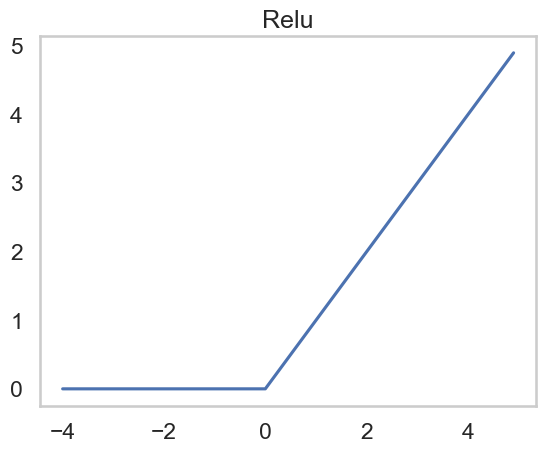

In [9]:
plt.plot(x,relu)
plt.title("Relu")
plt.grid()
plt.show()

## **2.4 Comparación**

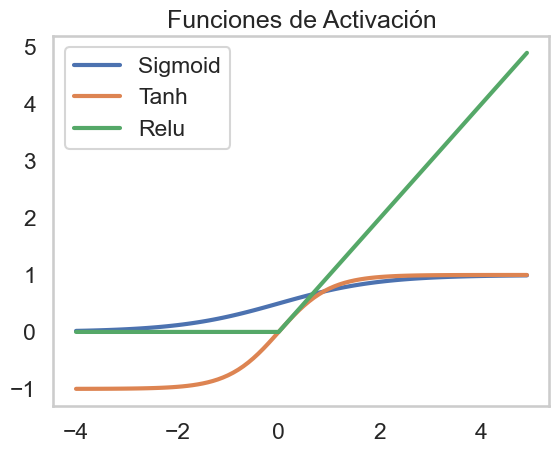

In [10]:
plt.plot(x,sig, label="Sigmoid", linewidth=3)
plt.plot(x,tan, label="Tanh",linewidth=3)
plt.plot(x,relu, label="Relu",linewidth=3)
plt.title("Funciones de Activación")
plt.grid()
plt.legend()
plt.show()

# **3. Descenso del Gradiente**
Implementaremos el método de regresion lineal simple utilizando NumpPy

In [11]:
df = pd.read_csv("https://raw.githubusercontent.com/EdwinEscobedo/Datasets/refs/heads/main/USA_Housing.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


* Para medir el error de nuestro Modelo, utilizamos el Error cuadratico médio:

 $rmse = \sqrt{(\frac{1}{n})\sum_{i=1}^{n}(y_{i} - p_{i})^{2}}$


In [12]:
def RMSE(y_true, y_pred):
  rmse = np.sqrt(np.sum((y_true - y_pred)**2)/y_true.size)
  return rmse

Exploremos el descenso del gradiente:

 <img src="https://miro.medium.com/max/694/1*7030GXGlVD-u9VyqVJdTyw.png" alt="Simply Easy Learning" width="500" height="250">

Veamos mejor este ejemplo de una forma animada:
[An Interactive Tutorial on Numerical Optimization](http://www.benfrederickson.com/numerical-optimization/)


  <img src="https://developers.google.com/machine-learning/glossary/images/nonconvex_function.svg?hl=es" alt="Simply Easy Learning" width="280">

**RESOLVAMOS EL PROBLEMA  CON LA BASE BOSTON**

Recordemos la ecuación de una recta:

$Y=W_0+W_1X$

Las derivadas parciales son:

$W_0=W_0-\alpha \frac{\partial }{\partial W_0}e(W_0,W_1)$

$W_1=W_1-\alpha \frac{\partial }{\partial W_1}e(W_0,W_1)$

Resolviendo:

$W_0=W_0-\alpha \frac{1}{m}\sum_{i=1}^{m}(h(x^{i})-y^{i})$


$W_1=W_1-\alpha \frac{1}{m}\sum_{i=1}^{m}((h(x^{i})-y^{i})x^{i})$


In [13]:
def gradient_descent(features, target, initial_bias, initial_weight, learning_rate, num_epochs):
  num_samples = target.size
  error_history = []
  # Reservado para una futura parada temprana si el error deja de mejorar.
  patience = 3

  current_bias = initial_bias
  current_weight = initial_weight

  for epoch in range(num_epochs):
    # Predicción lineal del modelo: y_hat = b + w * x
    predictions = current_bias + current_weight * features

    # Guardamos el error de esta época para visualizar el proceso de entrenamiento.
    error_history.append(RMSE(target, predictions))

    # Derivadas parciales del error respecto al sesgo y al peso.
    bias_gradient = np.sum(predictions - target)
    weight_gradient = np.sum((predictions - target) * features)

    # Regla de actualización del descenso del gradiente.
    current_bias = current_bias - (bias_gradient / num_samples) * learning_rate
    current_weight = current_weight - (weight_gradient / num_samples) * learning_rate

  return current_bias, current_weight, error_history

w0:23026.227951601388, w1:161680.11446299468


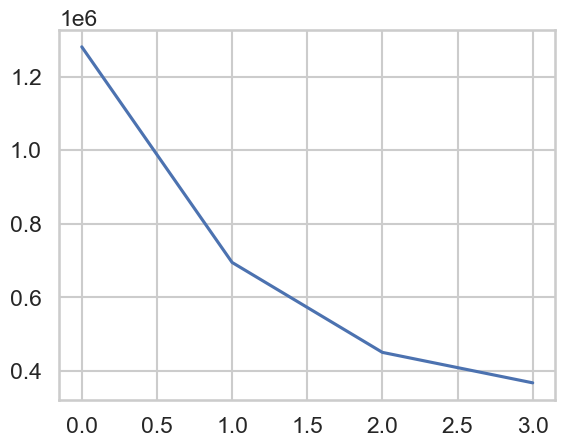

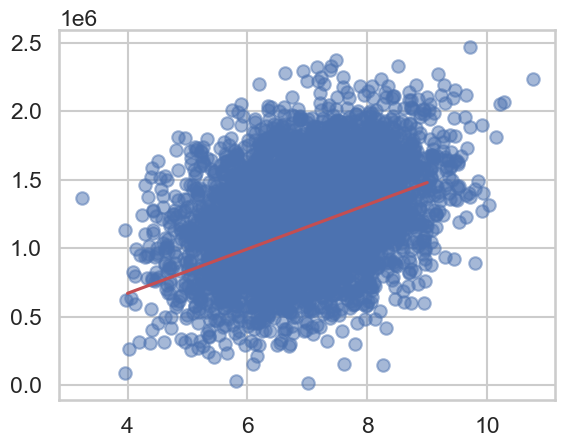

In [14]:
# Parámetros iniciales del descenso del gradiente
initial_bias = 40
initial_weight = 20
learning_rate = 0.01  # Paso de actualización pequeño para evitar oscilaciones
num_epochs = 4

# Variable independiente (característica) y variable objetivo
feature_values = np.array(df['Avg. Area Number of Rooms'])
target_values = np.array(df['Price'])

# Entrenamos el modelo lineal a mano
final_bias, final_weight, error_history = gradient_descent(
    feature_values,
    target_values,
    initial_bias,
    initial_weight,
    learning_rate,
    num_epochs,
 )

print(f"w0:{final_bias}, w1:{final_weight}")

# Evolución del error durante el entrenamiento
plt.plot(error_history)
plt.show()

# Recta ajustada sobre los datos originales
plt.scatter(feature_values, target_values, alpha=0.5)
plt.plot([4, 9], [final_bias + final_weight * 4, final_bias + final_weight * 9], "r")
plt.show()

# **4.Programando una ANN**

**Datos de entrenamiento**

Tenemos un datasets de dígitos escritos a mano que han sido etiquetados para que sepamos qué representa cada imagen, es decir, un número entre 0 y 9.

 <img src="https://codelabs.developers.google.com/static/codelabs/cloud-tensorflow-mnist/img/ad83f98e56054737.png" alt="Simply Easy Learning"
         width="2000">

         

La red neuronal que construiremos clasifica los dígitos escritos a mano en sus 10 clases (0, .., 9). Lo hace en base a parámetros internos que deben tener un valor correcto para que la clasificación funcione bien. Este `"valor correcto" `se aprende a través de un proceso de entrenamiento que requiere un "conjunto de datos etiquetados" con imágenes y las respuestas correctas asociadas.

A medida que avanza el entrenamiento, un lote de datos de entrenamiento a la vez, los parámetros internos del modelo se actualizan y el modelo mejora cada vez más en el reconocimiento de los dígitos escritos a mano. Puedes verlo en el gráfico de entrenamiento:

 <img src="https://codelabs.developers.google.com/static/codelabs/cloud-tensorflow-mnist/img/3f7b405649301ea.png" alt="Simply Easy Learning"
         width="2000">


**Predicciones**
Cuando el modelo está entrenado, podemos usarlo para reconocer dígitos escritos a mano. La siguiente visualización muestra qué tan bien funciona en unos pocos dígitos representados a partir de fuentes locales (primera línea) y luego en los 10 000 dígitos del conjunto de datos de validación. La clase predicha aparece debajo de cada dígito, en rojo si fue incorrecta.

 <img src="https://codelabs.developers.google.com/static/codelabs/cloud-tensorflow-mnist/img/c0699216ba0effdb.png" alt="Simply Easy Learning"
         width="2000">


**Tensores**

Los datos se almacenan en matrices. Una imagen en escala de grises de 28x28 píxeles cabe en una matriz bidimensional de 28x28. Pero para una imagen en color, necesitamos más dimensiones. Hay 3 valores de color por píxel (Rojo, Verde, Azul), por lo que se necesitará una tabla tridimensional con dimensiones [28, 28, 3]. Y para almacenar un lote de 128 imágenes en color, se necesita una tabla de cuatro dimensiones con dimensiones [128, 28, 28, 3].

Estas tablas multidimensionales se denominan "tensores" y la lista de sus dimensiones es su "forma" .

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu" )
device

device(type='cuda')

In [16]:
# Cargamos el conjunto de entrenamiento de MNIST.
# Cada imagen se transformará a tensor con valores entre 0 y 1.
train_data = datasets.MNIST(
    root="data",
    train=True,
    transform=ToTensor(),  # Convierte la imagen a tensor y normaliza los píxeles
    download=True
 )

# Cargamos el conjunto de prueba con la misma transformación.
test_data = datasets.MNIST(
    root="data",
    train=False,
    transform=ToTensor()
 )

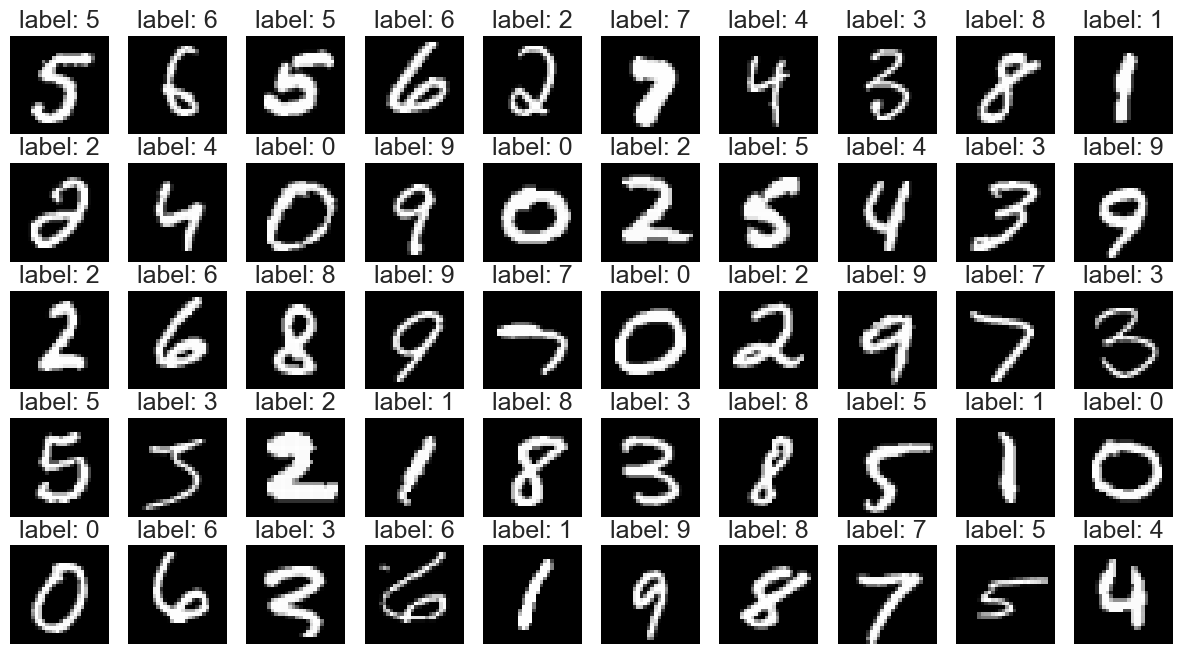

In [17]:
# Creamos una figura grande para mostrar varias imágenes de MNIST en una sola vista
figure = plt.figure(figsize=(15, 8))
# Organizamos la cuadrícula en filas y columnas
num_rows = 5
num_cols = 10

# Recorremos cada espacio de la cuadrícula y elegimos una imagen aleatoria del conjunto de entrenamiento
for index in range(1, num_rows * num_cols + 1):
  random_index = torch.randint(len(train_data), size=(1,)).item()
  image, label = train_data[random_index]

  # Añadimos la imagen a la posición correspondiente
  figure.add_subplot(num_rows, num_cols, index)
  plt.title(f"label: {label}")
  plt.axis("off")
  plt.imshow(image.squeeze(), cmap="gray")

plt.show()

## **Preparando los cargadores de datos**

Antes de entrenar la red, creamos dos `DataLoader`: uno para entrenamiento y otro para prueba.
Estos objetos permiten recorrer el dataset en lotes pequeños, barajando los datos de entrenamiento y
manteniendo fijo el conjunto de prueba para evaluar el modelo de forma consistente.

In [18]:
# Agrupamos ambos conjuntos en cargadores que entregan lotes al modelo.
# El conjunto de entrenamiento se baraja en cada época; el de prueba se mantiene fijo.
loaders = {
    "train": DataLoader(
        train_data,
        batch_size=100,
        shuffle=True,
        num_workers=0
    ),
    "test": DataLoader(
        test_data,
        batch_size=100,
        shuffle=False,
        num_workers=0
    )
}

## **Definiendo funciones de entrenamiento y pruebas**

In [19]:
def train_model(model, num_epochs, loaders, optimizer, loss_func):
  # Activamos el modo entrenamiento para que capas como Dropout o BatchNorm se comporten correctamente.
  model.train()

  num_batches = len(loaders["train"] )
  epoch_loss_history = []
  batch_loss_history = []

  for epoch in range(num_epochs):
    epoch_loss_sum = 0

    # Recorremos el conjunto de entrenamiento por lotes.
    for batch_index, (images, labels) in enumerate(loaders["train"]):
      # Limpiamos gradientes de la iteración anterior antes de calcular los nuevos.
      optimizer.zero_grad()

      # Aplanamos las imágenes de 28x28 a un vector de 784 elementos y las movemos al dispositivo.
      images = Variable(images.view(-1, 28 * 28)).to(device)
      labels = Variable(labels).to(device)

      # Paso hacia adelante y cálculo de la pérdida.
      outputs = model(images)
      loss = loss_func(outputs, labels)

      # Retropropagación y actualización de pesos.
      loss.backward()
      optimizer.step()

      # Acumulamos el error para reportarlo por época y por lote.
      current_loss = loss.item()
      epoch_loss_sum += current_loss
      batch_loss_history.append(current_loss)

      # Mostramos el progreso cada 100 lotes.
      if (batch_index + 1) % 100 == 0:
        print(f"epoch {epoch + 1}/{num_epochs}: step:{batch_index + 1}/{num_batches}, Loss:{current_loss:.4f}")

    # Guardamos el error promedio de la época.
    epoch_loss_history.append(epoch_loss_sum / num_batches)

  # Gráfica del error promedio por época.
  plt.plot(epoch_loss_history)
  plt.title("Gráfica del error")
  plt.xlabel("Epoca")
  plt.ylabel("Error")
  plt.grid()
  plt.show()

  # Gráfica del error en cada lote.
  plt.plot(batch_loss_history)
  plt.title("Gráfica del error por step")
  plt.xlabel("Epoca-step")
  plt.ylabel("Error")
  plt.grid()
  plt.show()

  return model

In [20]:
def test_model(model):
  # Cambiamos el modelo a modo evaluación para desactivar comportamientos de entrenamiento.
  model.eval()

  with torch.no_grad():
    total_correct = 0
    total_samples = 0
    batch_accuracy_history = []

    # Recorremos el conjunto de prueba lote por lote.
    for images, labels in loaders["test"]:
       # Aplanamos las imágenes igual que en entrenamiento y las movemos al dispositivo.
       images = images.view(-1, 28 * 28).to(device)
       labels = labels.to(device)

       # Obtenemos las predicciones del modelo.
       test_outputs = model(images)
       predicted_labels = torch.max(test_outputs, 1)[1].data.squeeze()

       # Contamos aciertos del lote actual y los acumulamos.
       batch_correct = (predicted_labels == labels).sum().item()
       batch_total = labels.size(0)
       total_correct += batch_correct
       total_samples += batch_total

       # Guardamos la precisión de cada lote para poder inspeccionarla si hace falta.
       batch_accuracy_history.append(batch_correct / batch_total)

    overall_accuracy = total_correct / total_samples if total_samples else 0
    print(f"Accuracy en test : {overall_accuracy}")
    return batch_accuracy_history

## **Configurando Parámetros**

In [21]:
# Tamaño de cada imagen al aplanarla: 28 x 28 píxeles = 784 valores.
input_size = 784

# Número de neuronas en la capa oculta de la red inicial.
hidden_size = 500

# Número total de clases que debe predecir el modelo (dígitos del 0 al 9).
num_classes = 10

# Cantidad de pasadas completas sobre el conjunto de entrenamiento.
num_epochs = 5

# Tamaño de cada lote de entrenamiento.
batch_size = 100

# Tasa de aprendizaje: controla qué tanto se ajustan los pesos en cada actualización.
lr = 1e-3

## **Modelo inicial**
 **Una red simple**

 <img src="https://codelabs.developers.google.com/static/codelabs/cloud-tensorflow-mnist/img/e218e6eee9da4e.png" alt="Simply Easy Learning"
         width="500">

In [22]:
# Modelo lineal más simple posible: una sola capa completamente conectada.
class net_ANN(nn.Module):
  def __init__(self, input_size, num_classes):
    super(net_ANN, self).__init__()

    # Esta capa toma el vector de entrada aplanado y produce directamente una salida por clase.
    self.fc1 = nn.Linear(input_size, num_classes)

  def forward(self, x):
    # En el paso hacia adelante, solo aplicamos la capa lineal definida arriba.
    outputs = self.fc1(x)
    return outputs

In [23]:
# Creamos la red con la arquitectura definida arriba.
model_ann = net_ANN(input_size, num_classes)

# Mostramos la estructura del modelo para confirmar sus dimensiones.
print(model_ann)

# Movemos el modelo al dispositivo elegido y preparamos la función de pérdida y el optimizador.
model_ann.to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_ann.parameters(), lr=lr)

net_ANN(
  (fc1): Linear(in_features=784, out_features=10, bias=True)
)


epoch 1/5: step:100/600, Loss:2.2082
epoch 1/5: step:200/600, Loss:2.1638
epoch 1/5: step:300/600, Loss:2.0731
epoch 1/5: step:400/600, Loss:1.9733
epoch 1/5: step:500/600, Loss:1.8560
epoch 1/5: step:600/600, Loss:1.7727
epoch 2/5: step:100/600, Loss:1.7546
epoch 2/5: step:200/600, Loss:1.7206
epoch 2/5: step:300/600, Loss:1.6083
epoch 2/5: step:400/600, Loss:1.5937
epoch 2/5: step:500/600, Loss:1.5465
epoch 2/5: step:600/600, Loss:1.5097
epoch 3/5: step:100/600, Loss:1.4316
epoch 3/5: step:200/600, Loss:1.4290
epoch 3/5: step:300/600, Loss:1.4085
epoch 3/5: step:400/600, Loss:1.2995
epoch 3/5: step:500/600, Loss:1.3508
epoch 3/5: step:600/600, Loss:1.2651
epoch 4/5: step:100/600, Loss:1.2593
epoch 4/5: step:200/600, Loss:1.2539
epoch 4/5: step:300/600, Loss:1.1820
epoch 4/5: step:400/600, Loss:1.1763
epoch 4/5: step:500/600, Loss:1.1043
epoch 4/5: step:600/600, Loss:1.0874
epoch 5/5: step:100/600, Loss:1.0751
epoch 5/5: step:200/600, Loss:1.0141
epoch 5/5: step:300/600, Loss:1.0877
e

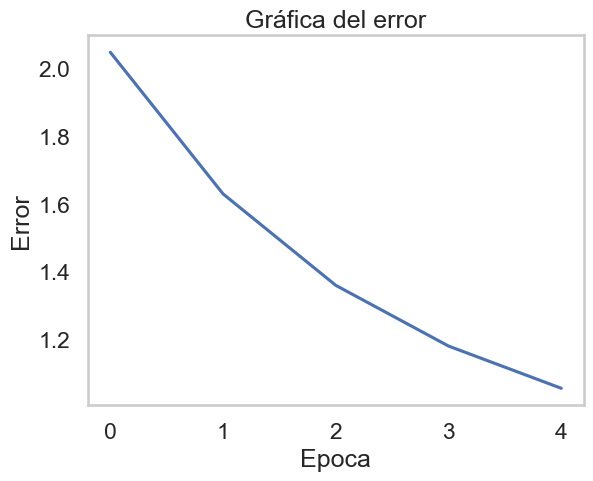

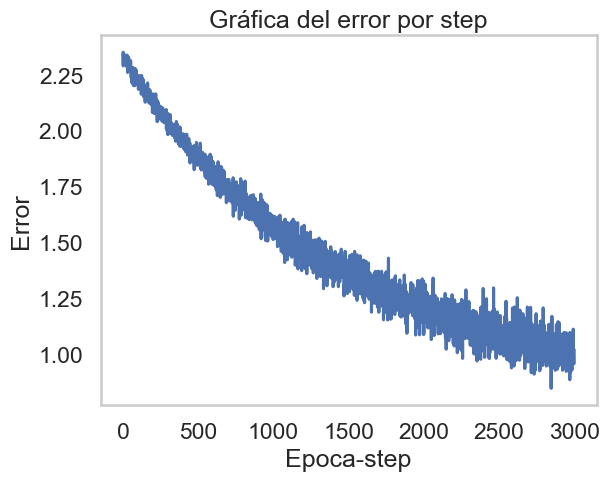

CPU times: total: 39.8 s
Wall time: 14 s


In [24]:
%%time
# %%time es específico de Jupyter para medir el tiempo de ejecución del bloque de código.
# Entrenamos el primer modelo usando la función definida arriba.
model_ann = train_model(model_ann, num_epochs, loaders, optimizer, loss_func)

In [25]:
test_model(model_ann); # Se usa ; para evitar que Jupyter muestre la lista de precisiones por lote, que no es relevante en este caso.

Accuracy en test : 0.8282


## **Agregando capas**
 <img src="https://codelabs.developers.google.com/static/codelabs/cloud-tensorflow-mnist/img/a01d1ffdc3c7aa7d.png" alt="Simply Easy Learning"
         width="500">

In [26]:
class net_ANN2(nn.Module):
  def __init__(self, input_size, num_classes):
    super(net_ANN2, self).__init__()

    # Primera proyección: transforma el vector de entrada de 784 valores en una representación más compacta.
    self.hidden_layer_1 = nn.Linear(input_size, 200)

    # Usamos la misma función de activación en todas las capas ocultas para mantener el ejemplo simple.
    self.activation = nn.Sigmoid()

    # Capas intermedias que van reduciendo progresivamente la dimensión de la representación.
    self.hidden_layer_2 = nn.Linear(200, 100)
    self.hidden_layer_3 = nn.Linear(100, 60)
    self.hidden_layer_4 = nn.Linear(60, 30)

    # Capa de salida: produce un valor por clase, uno para cada dígito del 0 al 9.
    self.output_layer = nn.Linear(30, num_classes)

  def forward(self, inputs):
    # Paso 1: proyección inicial.
    hidden_representation = self.hidden_layer_1(inputs)
    hidden_representation = self.activation(hidden_representation)

    # Paso 2: refinamos la representación aprendida con más capas densas.
    hidden_representation = self.hidden_layer_2(hidden_representation)
    hidden_representation = self.activation(hidden_representation)

    hidden_representation = self.hidden_layer_3(hidden_representation)
    hidden_representation = self.activation(hidden_representation)

    hidden_representation = self.hidden_layer_4(hidden_representation)
    hidden_representation = self.activation(hidden_representation)

    # Paso final: generamos los logits de salida, uno por clase.
    logits = self.output_layer(hidden_representation)
    return logits

In [27]:
# Instanciamos la red más profunda definida arriba para trabajar con MNIST.
model_ann = net_ANN2(input_size, num_classes)

# Mostramos su estructura para verificar cómo quedaron conectadas las capas.
print(model_ann)

# Movemos el modelo al dispositivo elegido y preparamos los elementos de entrenamiento.
model_ann.to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ann.parameters(), lr=lr)

net_ANN2(
  (hidden_layer_1): Linear(in_features=784, out_features=200, bias=True)
  (activation): Sigmoid()
  (hidden_layer_2): Linear(in_features=200, out_features=100, bias=True)
  (hidden_layer_3): Linear(in_features=100, out_features=60, bias=True)
  (hidden_layer_4): Linear(in_features=60, out_features=30, bias=True)
  (output_layer): Linear(in_features=30, out_features=10, bias=True)
)


epoch 1/5: step:100/600, Loss:2.1818
epoch 1/5: step:200/600, Loss:1.6814
epoch 1/5: step:300/600, Loss:1.5505
epoch 1/5: step:400/600, Loss:1.3329
epoch 1/5: step:500/600, Loss:1.0812
epoch 1/5: step:600/600, Loss:0.9638
epoch 2/5: step:100/600, Loss:0.8132
epoch 2/5: step:200/600, Loss:0.7760
epoch 2/5: step:300/600, Loss:0.7332
epoch 2/5: step:400/600, Loss:0.7353
epoch 2/5: step:500/600, Loss:0.5378
epoch 2/5: step:600/600, Loss:0.5220
epoch 3/5: step:100/600, Loss:0.3612
epoch 3/5: step:200/600, Loss:0.3612
epoch 3/5: step:300/600, Loss:0.2864
epoch 3/5: step:400/600, Loss:0.3385
epoch 3/5: step:500/600, Loss:0.2112
epoch 3/5: step:600/600, Loss:0.2544
epoch 4/5: step:100/600, Loss:0.1797
epoch 4/5: step:200/600, Loss:0.1642
epoch 4/5: step:300/600, Loss:0.2198
epoch 4/5: step:400/600, Loss:0.1912
epoch 4/5: step:500/600, Loss:0.1030
epoch 4/5: step:600/600, Loss:0.1592
epoch 5/5: step:100/600, Loss:0.1279
epoch 5/5: step:200/600, Loss:0.0867
epoch 5/5: step:300/600, Loss:0.0737
e

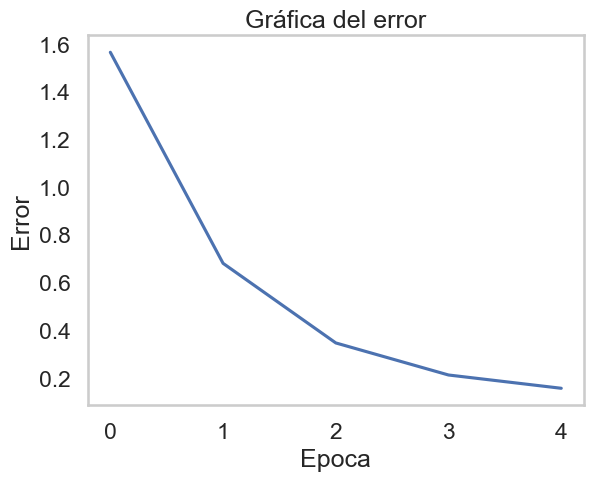

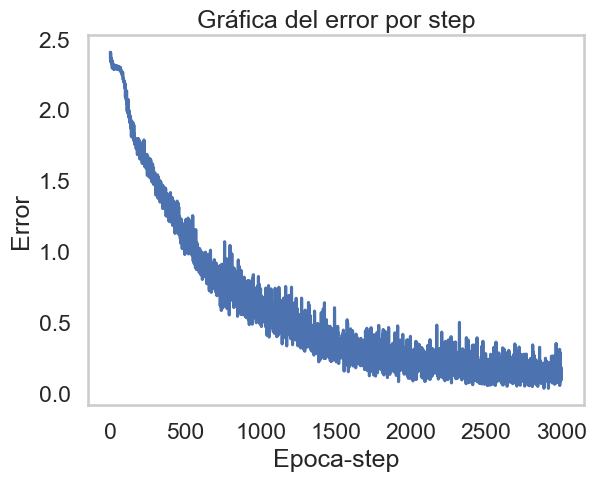

CPU times: total: 44.3 s
Wall time: 18.6 s


In [28]:
%%time
model_ann = train_model(model_ann, num_epochs, loaders, optimizer, loss_func)

In [29]:
test_model(model_ann);

Accuracy en test : 0.954


<img src="https://codelabs.developers.google.com/static/codelabs/cloud-tensorflow-mnist/img/5236f91ba6e07d85.png" alt="Simply Easy Learning"
         width="800">
<img src="https://codelabs.developers.google.com/static/codelabs/cloud-tensorflow-mnist/img/41fc82288c4aff5d.png" alt="Simply Easy Learning"
         width="300">

**¡CUIDADO CON LA PÉRDIDA DEL GRADIENTE!**

Cuando una red se vuelve más profunda, las señales de error pueden debilitarse a medida que retroceden por las capas. Eso dificulta el aprendizaje y hace que las primeras capas se actualicen muy poco.

## **RELU + un mejor optimizador**

Para mitigar ese problema, solemos combinar dos ideas:
- usar **ReLU** como función de activación, porque mantiene mejor el flujo del gradiente;
- usar un optimizador más robusto, como **Adam**, que ajusta los pasos de entrenamiento de forma más estable.

https://machinelearningmastery.com/adam-optimization-algorithm-for-deep-learning/

<img src="https://codelabs.developers.google.com/static/codelabs/cloud-tensorflow-mnist/img/35a0e96b3da8a465.png" alt="Simply Easy Learning"
         width="600">

<img src="https://codelabs.developers.google.com/static/codelabs/cloud-tensorflow-mnist/img/1abce89f7143a69c.png" alt="Simply Easy Learning"
         width="300">

In [30]:
# Número de neuronas de la capa oculta para la red con ReLU.
# Este valor controla la capacidad del modelo: más neuronas = más flexibilidad, pero también más costo y riesgo de sobreajuste.
hidden_size = 200

In [31]:
class net_ANN_R(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super(net_ANN_R, self).__init__()

    # La primera capa transforma la imagen aplanada en una representación intermedia.
    self.hidden_layer = nn.Linear(input_size, hidden_size)

    # ReLU introduce no linealidad y ayuda a que el modelo aprenda patrones más complejos.
    self.activation = nn.ReLU()

    # La capa de salida convierte la representación intermedia en una puntuación por clase.
    self.output_layer = nn.Linear(hidden_size, num_classes)

  def forward(self, inputs):
    # Primero proyectamos la entrada en el espacio oculto.
    hidden_representation = self.hidden_layer(inputs)

    # Después aplicamos ReLU para conservar solo las activaciones positivas.
    hidden_representation = self.activation(hidden_representation)

    # Finalmente obtenemos los logits, uno por cada dígito posible.
    logits = self.output_layer(hidden_representation)
    return logits

In [32]:
# Instanciamos la red con una capa oculta y activación ReLU definida arriba.
model_annr = net_ANN_R(input_size, hidden_size, num_classes)

# Mostramos su estructura para verificar que la arquitectura quedó como esperamos.
print(model_annr)

# Movemos el modelo al dispositivo elegido y preparamos la función de pérdida y el optimizador.
model_annr.to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_annr.parameters(), lr=lr)

net_ANN_R(
  (hidden_layer): Linear(in_features=784, out_features=200, bias=True)
  (activation): ReLU()
  (output_layer): Linear(in_features=200, out_features=10, bias=True)
)


epoch 1/5: step:100/600, Loss:0.3266
epoch 1/5: step:200/600, Loss:0.3356
epoch 1/5: step:300/600, Loss:0.2430
epoch 1/5: step:400/600, Loss:0.2817
epoch 1/5: step:500/600, Loss:0.1628
epoch 1/5: step:600/600, Loss:0.2155
epoch 2/5: step:100/600, Loss:0.1143
epoch 2/5: step:200/600, Loss:0.1482
epoch 2/5: step:300/600, Loss:0.2034
epoch 2/5: step:400/600, Loss:0.1784
epoch 2/5: step:500/600, Loss:0.1580
epoch 2/5: step:600/600, Loss:0.1139
epoch 3/5: step:100/600, Loss:0.1206
epoch 3/5: step:200/600, Loss:0.0375
epoch 3/5: step:300/600, Loss:0.0636
epoch 3/5: step:400/600, Loss:0.0691
epoch 3/5: step:500/600, Loss:0.0339
epoch 3/5: step:600/600, Loss:0.1255
epoch 4/5: step:100/600, Loss:0.0550
epoch 4/5: step:200/600, Loss:0.1073
epoch 4/5: step:300/600, Loss:0.1577
epoch 4/5: step:400/600, Loss:0.0787
epoch 4/5: step:500/600, Loss:0.1091
epoch 4/5: step:600/600, Loss:0.0168
epoch 5/5: step:100/600, Loss:0.0535
epoch 5/5: step:200/600, Loss:0.0211
epoch 5/5: step:300/600, Loss:0.0679
e

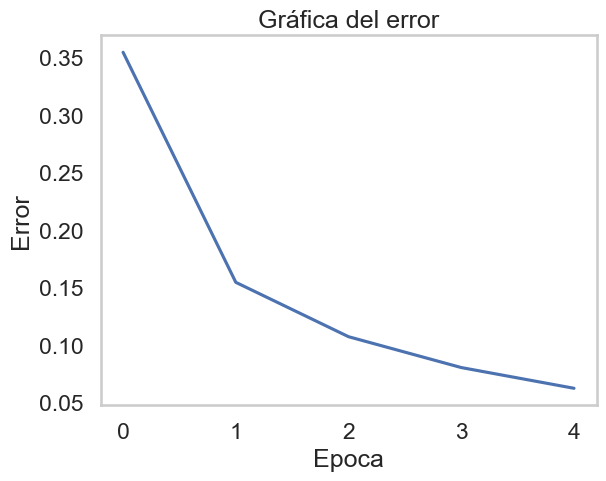

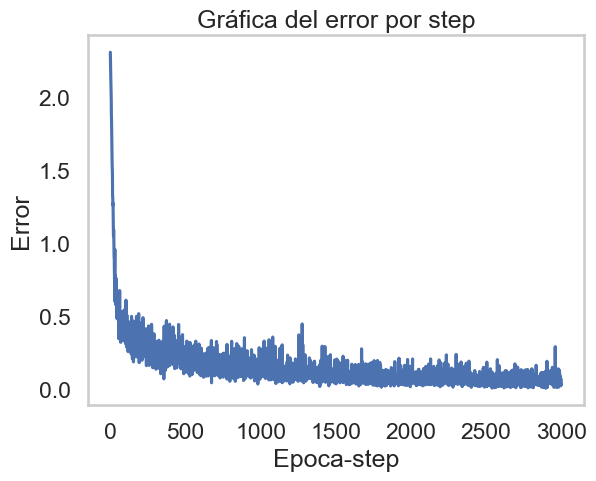

CPU times: total: 43.7 s
Wall time: 17.7 s


In [33]:
%%time
model_annr = train_model(model_annr, num_epochs, loaders, optimizer, loss_func)

In [34]:
test_model(model_annr);

Accuracy en test : 0.9745


Para explorar una demostración interactiva del clasificador de dígitos, puedes abrir este recurso externo.
Es útil como complemento visual para comparar distintas formas de representación de MNIST:
https://cs.stanford.edu/people/karpathy/convnetjs/demo/mnist.html

La animación final refuerza la idea de que el entrenamiento no ocurre de golpe: los parámetros se van ajustando iterativamente hasta mejorar la predicción.
Es un buen cierre visual para conectar la teoría con el comportamiento real de una red neuronal entrenada.

<img src="https://miro.medium.com/v2/resize:fit:828/0*u5-PcKYVfUE5s2by.gif" alt="Simply Easy Learning"
         width="500">